In [1]:
import pandas as pd

Processing 2000-01: 191,664 shots
Processing 2001-02: 193,263 shots
Processing 2002-03: 192,109 shots
Processing 2003-04: 189,803 shots
Processing 2004-05: 163,917 shots
Processing 2005-06: 194,314 shots
Processing 2006-07: 189,716 shots
Processing 2007-08: 154,254 shots
Processing 2008-09: 185,992 shots
Processing 2009-10: 200,989 shots
Processing 2010-11: 199,790 shots
Processing 2011-12: 161,225 shots
Processing 2012-13: 201,609 shots
Processing 2013-14: 204,172 shots
Processing 2014-15: 205,570 shots
Processing 2015-16: 208,049 shots
Processing 2016-17: 210,114 shots
Processing 2017-18: 211,707 shots
Processing 2018-19: 219,458 shots
Processing 2019-20: 188,116 shots
Processing 2020-21: 190,983 shots
Processing 2021-22: 216,722 shots
Processing 2022-23: 217,220 shots
Processing 2023-24: 218,700 shots
Processing 2024-25: 219,527 shots
Processing 2025-26: 26,136 shots


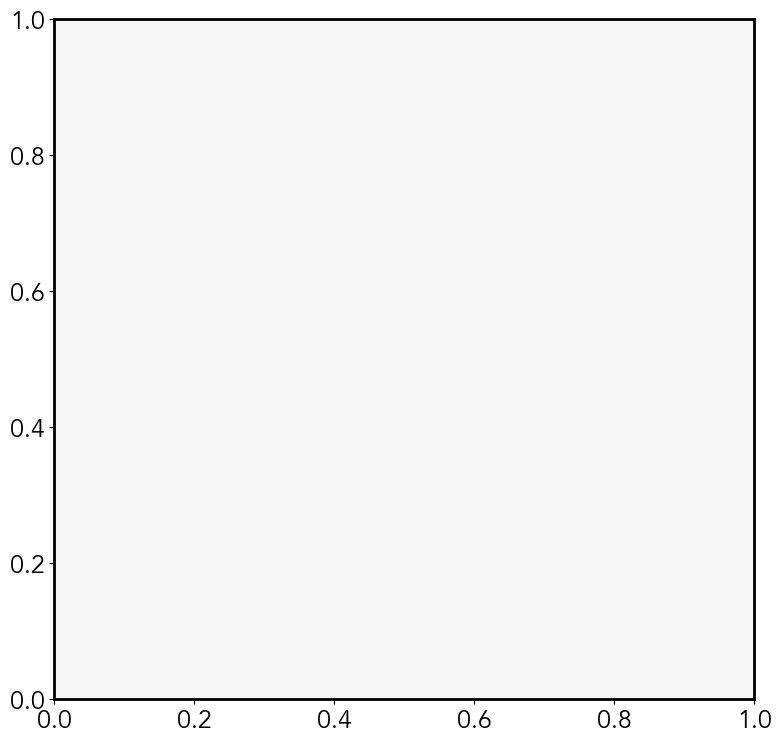

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from draw_shot_chart import create_court, draw_shots_hex
from matplotlib.colors import LogNorm

# Set up the figure with light gray background
fig = plt.figure(figsize=(7, 6.8))
ax = fig.add_axes([0, 0, 1, 1], facecolor="#f7f7f7")


seasons = [f"{yr}-{str(yr+1)[-2:]}" for yr in range(2000, 2026)]

for season in seasons:
    fname = f"nba_shots_{season}_all.csv"
    try:
        data = pd.read_csv(fname)
    except FileNotFoundError:
        print(f"File not found: {fname} — skipping.")
        continue

    print(f"Processing {season}: {len(data):,} shots")

    # create a new figure/axis for each season
    fig = plt.figure(figsize=(7, 6.8))
    ax = fig.add_axes([0, 0, 1, 1], facecolor="#f7f7f7")

    # prepare coordinates (shift Y to half-court)
    x = data["LOC_X"].to_numpy()
    y = (data["LOC_Y"] + 60).to_numpy()

    hb = ax.hexbin(
        x, y,
        gridsize=35,
        extent=[-250, 250, 0, 470],
        mincnt=200,
        linewidths=0,
        edgecolors='none',
        cmap='RdYlGn_r',
        norm=LogNorm(),
    )

    create_court(ax, 'black')

    ax.text(0, 450, f'NBA Shot Chart - {season}',
            ha='center', va='top', color='black', fontsize=16,
            fontfamily='DejaVu Sans', fontweight='bold')

    # small horizontal legend (colorbar) in the upper-right corner
    # coordinates are figure-relative [left, bottom, width, height]
    cax = fig.add_axes([0.68, 0.86, 0.28, 0.02])  # moved slightly lower
    cbar = fig.colorbar(hb, cax=cax, orientation='horizontal')
    cbar.set_label('Shot count (log scale)', fontsize=8, color='black')
    cbar.ax.tick_params(labelsize=8)

    # small footnote
    ax.text(0.01, 0.01, 'Source: NBA Stats.', ha='left', va='bottom',
            transform=ax.transAxes, fontsize=8, color='gray')

    plt.savefig(f'nba_shot_chart_{season}_hexbin.png', dpi=300, bbox_inches='tight')
    plt.close(fig)

In [3]:
import imageio
import os

# Use existing images list if already built; otherwise build it
try:
    imgs = images
except NameError:
    imgs = []
    for season in seasons:
        fname = f'nba_shot_chart_{season}_hexbin.png'
        if os.path.exists(fname):
            imgs.append(imageio.imread(fname))

if imgs:
    # Increase these to slow the animation
    default_duration = 2    # seconds per frame (was 1)
    extra_last_frame = 8    # seconds to hold the last frame (was 5)

    durations = [default_duration] * len(imgs)
    durations[-1] = extra_last_frame

    imageio.mimsave('nba_shot_chart.gif', imgs, duration=durations, loop=0)

/var/folders/jd/5wy1jytx2pg8j4jr12tl0k_m0000gq/T/ipykernel_40789/3859684113.py:12: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  imgs.append(imageio.imread(fname))
